# Calculate Effective Penetration Depth (EPD) of Simulated Tissues and Phantoms

In [1]:
# imports
import numpy as np
import simpa as sp
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# load data: 20 x 20 x 20 mm volumes, spacing = 0.10 (100um spacing)

# 450 to 1599 nm in 10 nm steps [num for num in range(450, 1599, 10)]

# paths to tissues and phantoms simulation results
#PATH = r'/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/Data/Simulation_results_2026-05-17/'
PATH = r'D:\OneDrive - University of Cambridge\PhD\Lab work\Biomolecule characterisation\Data_and_Code\Data\Simulation_results_2026-05-17/'
agar = PATH + 'Agar.hdf5'
copolymer = PATH + 'copolymer.hdf5'
PDMS = PATH + 'PDMS.hdf5'
muscle = PATH + 'muscle.hdf5'
fat = PATH + 'fat.hdf5'

In [3]:
def calc_EPD(fluence_data, Z_length, spacing=0.10, target_fluence=0.37):
    """
    Calculates the effective penetration depth (EPD) of by finding where fluence drops to 1/e of initial value.
    
    fluence_data: SIMPA fluence = sp.load_data_field(path, sp.Tags.DATA_FIELD_FLUENCE, wavelength),
    Z_length: depth of simulated tissue/phantom [mm],
    spacing: voxel spacing [mm],
    target_fluence: fluence at which we want to find the depth,
    
    return: depth at which fluence = target_fluence
    """
    # Calculate the physical area of one voxel face
    voxel_area = spacing**2 # [mm^2]
    
    # Integrate fluence over the X-Y plane for each Z coordinate (gives 1D output)
    fl_integrated = np.sum(fluence_data[:, :, :], axis=(0, 1)) * voxel_area # [J/mm^2] x [mm^2] = [J]
    
    # Normalise to maximum fluence
    fl_normalised = fl_integrated / np.max(fl_integrated)
    
    # Create array with Z coordinates [mm]
    Z_coord = np.linspace(0, Z_length, fluence_data.shape[2])
    
    # Find index where the fluence value is closest to the target fluence
    target_index = np.argmin(np.abs(fl_normalised - target_fluence))
    
    # Find the depth corresponding to the target fluence index
    depth = Z_coord[target_index]
    
    return depth


def process_EPD(path, Zlength, wavelength_range):
    """
    Calculates EPD across a range of wavelengths.
    
    path: SIMPA fluence = sp.load_data_field(path, sp.Tags.DATA_FIELD_FLUENCE, wavelength),
    Z_length: depth of simulated tissue/phantom [mm],
    wavelength_range: range of wavelengths of interest (must be wavelengths sampled in simulation, i.e. no interpolation)
    
    return: list of EPD values over wavelength_range.
    """    
    # Define list to fill with calculated EPD values
    EPD_list = []
    
    # Loop through wavelength range
    for i in wavelength_range:
        # Extract fluence
        fluence = sp.load_data_field(path, sp.Tags.DATA_FIELD_FLUENCE, i)
        # Calculate EPD
        EPD = calc_EPD(fluence, Zlength, spacing=0.10, target_fluence=0.37)
        # Append to list
        EPD_list.append(EPD)

    return EPD_list

In [4]:
# plain blocks of material
wavelength_range = range(450, 1599, 10)
Zlength = 20
depth_agar = process_EPD(agar, Zlength, wavelength_range)
depth_copolymer = process_EPD(copolymer, Zlength, wavelength_range)
depth_PDMS = process_EPD(PDMS, Zlength, wavelength_range)
depth_muscle = process_EPD(muscle, Zlength, wavelength_range)
depth_fat = process_EPD(fat, Zlength, wavelength_range)

In [5]:
df = pd.DataFrame({'nm': wavelength_range, 'Agar[mm]':depth_agar, 'PDMS[mm]':depth_PDMS, 'copolymer[mm]':depth_copolymer,
                  'muscle[mm]':depth_muscle, 'fat[mm]':depth_fat})

# Save to a .txt file
df.to_csv('D:\OneDrive - University of Cambridge\PhD\Lab work\Biomolecule characterisation\Data_and_Code\Data\Simulation_results_2026-05-17\EPD.txt', sep='\t', index=False)

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
C:\Users\mjw233\AppData\Local\Temp\ipykernel_11680\1507340165.py:5: SyntaxWarning: invalid escape sequence '\O'
  df.to_csv('D:\OneDrive - University of Cambridge\PhD\Lab work\Biomolecule characterisation\Data_and_Code\Data\Simulation_results_2026-05-17\EPD.txt', sep='\t', index=False)


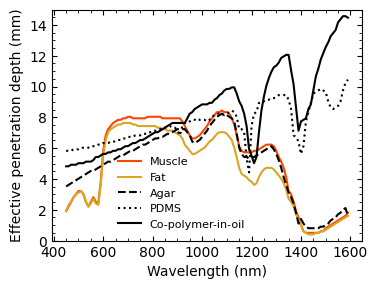

In [6]:
fig = plt.figure(figsize=(4, 3))
dpi = 300
wavelengths = [num for num in range(450, 1599, 10)]

plt.plot(wavelengths, depth_muscle, c='orangered', marker='', ls='-', label='Muscle', lw=1.5)
plt.plot(wavelengths, depth_fat, c='goldenrod', marker='', ls='-', label='Fat', lw=1.5)
plt.plot(wavelengths, depth_agar, c='k', marker='', ls='--', label='Agar', lw=1.5)
plt.plot(wavelengths, depth_PDMS, c='k', marker='', ls=':', label='PDMS', lw=1.5)
plt.plot(wavelengths, depth_copolymer, c='k', marker='', ls='-', label='Co-polymer-in-oil', lw=1.5)

#plt.ylim(0.5,4)
plt.xlabel('Wavelength (nm)', fontsize=10)
plt.ylabel('Effective penetration depth (mm)', fontsize=10)
plt.tick_params(axis='both', which='both', direction='in', labelsize=10, top=True, right=True)
plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.74))
plt.legend(loc=[0.2,0.03], fontsize=8, frameon=False)
plt.ylim(0,15)
plt.tick_params(axis='both', which='both', direction='in', labelsize=10, top=True, right=True, bottom=True)
plt.minorticks_on()

#plt.savefig('EPD_BMC_v2.png', dpi=300, bbox_inches='tight')